<a href="https://colab.research.google.com/github/ashleybrea/DataScience-HW04-2/blob/main/Ashley_Brea_~_HW04_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science

## Notebook 4 (Character recognition with Keras)

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

dir = '/content/drive/MyDrive/ait'

Mounted at /content/drive


### Character recoginition with Keras

(Thanks to Róbert Pálovics and József Pintér)

In [3]:
# imports for plotting and displaying the data
from IPython.core.display import HTML
HTML("<style>.container { width:100% !important; }</style>")
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from PIL import ImageOps
import numpy as np
from matplotlib.pyplot import imshow
sns.set(font="Droid Sans",font_scale = 1)
sns.set_style("white")
sns.set_color_codes("dark")

Training neaural networks is just a bunch of matrix multiplication and dot products, and this is why GPU's are good.


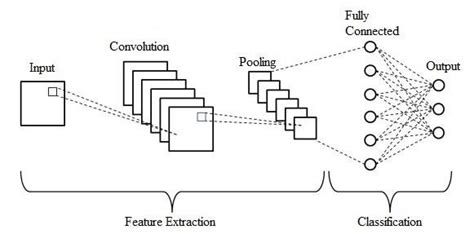

In [ ]:
# from IPython.display import Image
# Image(dir+"/architecture.jpg",width=600)

How a convolutional Network look like, like the einstein side in class

#### MNIST Dataset
* 70,000 pictures of handwritten digits
* 28x28 pixel grayscale images, so there are 28x28 = 784 attributes each with values 0-255
* <span style="color:red">How many attributes would there be for a 28X28 RGB image?</span>
* Possible labels: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9 (multi-class classifcation)
* <span style="color:red">Is a neural net a good choice for this data? Why / what problems are neural nets best suited for?</span>

In [4]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_test.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(10000, 28, 28)

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
a = x_train[0]

for line in a:
    print ('  '.join(map(str, line)))

0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
0  0  0  0  0  0  0  0  0  0  0  0  3  18  18  18  126  136  175  26  166  255  247  127  0  0  0  0
0  0  0  0  0  0  0  0  30  36  94  154  170  253  253  253  253  253  225  172  253  242  195  64  0  0  0  0
0  0  0  0  0  0  0  49  238  253  253  253  253  253  253  253  253  251  93  82  82  56  39  0  0  0  0  0
0  0  0  0  0  0  0  18  219  253  253  253  253  253  198  182  247  241  0  0  0  0  0  0  0  0  0  0
0  0  0  0  0  0  0  0  80  156  107  253  253  205  11  0  43  154  0  0  0  0  0  0  0  0  0  0
0  0  0  0  0  0  0  0  0  14  1  154  253  90  0  0  0  0  0 

<class 'numpy.ndarray'>
(28, 28, 1)


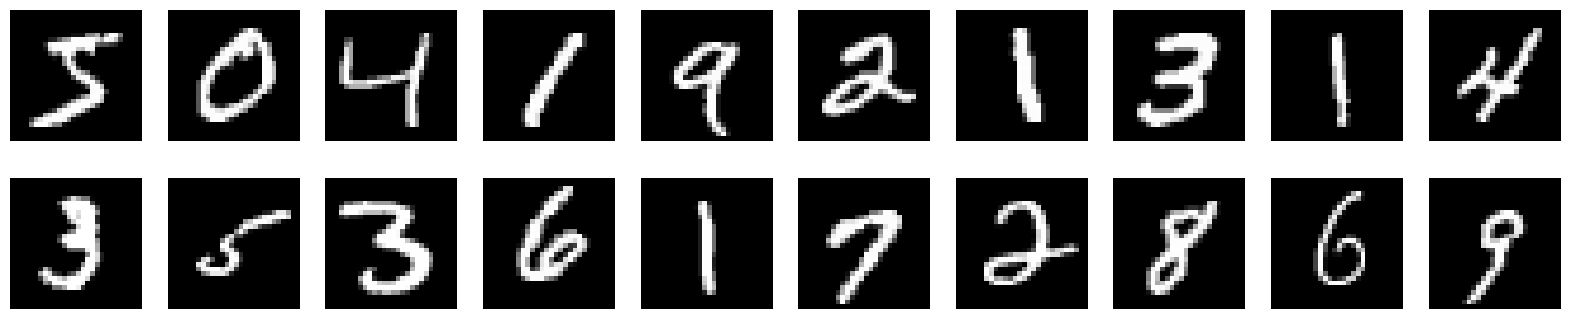

In [55]:
plt.figure(figsize=(20,4))
for i in range(20):
  plt.subplot(2,10,i+1)
  plt.axis('off')
  plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))

In [8]:
print(y_train.shape)
y_train[0:20]

(60000,)


array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9],
      dtype=uint8)

#### Reformatting the data
- Values between 0-1
- Tensorflow takes in 4dim data as an input: the number of records, the height of the image, the width of the image, the number of channels (1 for grayscale images, 3 for RGB images). Use -1 for the number of records because it is dynamic.
- Make sure data is all of the same type
- Change label values 0-9 to len=10 arrays, <span style="color:red">why?</span>

In [9]:
# rescale the data to numbers between 0-1, by convention and to improve training efficiency
x_train = x_train / 255 # we use 255 because thats the scale used for darkness range
x_test = x_test / 255

# store the pictures in an appropriate tensor 28x28 pictures with only 1 channel
# the -1 parameter indicates keras should infer the shape of the matrix (in this case 60000)
x_train = x_train.reshape(-1,28,28,1) # pixels are 28x28
x_test = x_test.reshape(-1,28,28,1)

# tensorflow will not perform the necessary operations if data is stored as different types
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")


# change target variable to categorical attribute (one-hot-encoding):
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [10]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [11]:
a = np.round(x_train[0],decimals=1)
p = ""
for line in a:
    for i in range(0,len(line)):
        p += str(line[i][0])#; p += ""
    print(p); p = ""

0.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.0
0.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.0
0.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.0
0.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.0
0.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.00.0
0.00.00.00.00.00.00.00.00.00.00.00.00.00.10.10.10.50.50.70.10.71.01.00.50.00.00.00.0
0.00.00.00.00.00.00.00.00.10.10.40.60.71.01.01.01.01.00.90.71.00.90.80.30.00.00.00.0
0.00.00.00.00.00.00.00.20.91.01.01.01.01.01.01.01.01.00.40.30.30.20.20.00.00.00.00.0
0.00.00.00.00.00.00.00.10.91.01.01.01.01.00.80.71.00.90.00.00.00.00.00.00.00.00.00.0
0.00.00.00.00.00.00.00.00.30.60.41.01.00.80.00.00.20.60.00.00.00.00.00.00.00.00.00.0
0.00.00.00.00.00.00.00.00.00.10.00.61.00.40.00.00.00.00.00.00.00.00.00.00.00.00.00.0
0.00.00.00.00.00.00.00.00.00.00.00.51.00.70.00.00.00.00.00.00.00.

 #### Modeling

We are going to build the following model:

| layer        | filters   | filter size| sride length | activation | output dimension |
|--------------|-----------|------------|--------------|------------|------------------|
| Conv2D       |  32       | 5x5        | 1            | relu       | 24x24            |
| Conv2D       | 64        | 5x5        | 1            | relu       | 20x20            |
| MaxPooling2D |  -        | 2x2        | 2            | -          | 10x10            |
| Flatten()    |  -        | -          | -            | -          | -                |
| Dense(output)|  -        | -          | -            | softmax    | ?                |

#### Convolutional (feature mapping) layer
Terminology: stride length, kernel/filter size, channels

Function: w1 * in1 + w2 * in2 + w3 * in3 + w4 * in4 + b

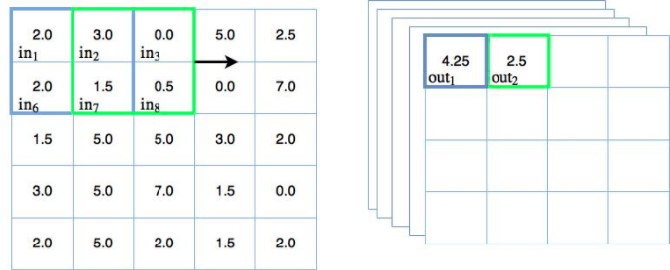

In [ ]:
# from IPython.display import Image as DisplayImage
# DisplayImage(filename=dir+"/CNN_feature_mapping.png")

#### Pooling (down sampling) layer
Terminology: padding

Function: max()

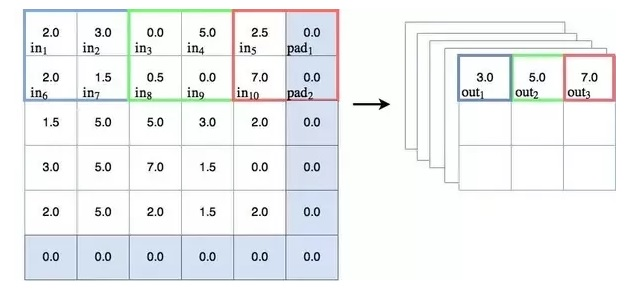

In [ ]:
# DisplayImage(filename=dir+"/CNN_pooling.jpg")

#### Flatten
The output of the covolution and pooling layers contain new high-level data features which describe the input image rather than the low-level pixel data we started with. These need to be "flattened" into a vector which becomes the input into the last fully-connected or "dense" layer of the CNN - like tagging a simple neural network classifier onto the end. Neural networks are good at dimention reduction and feature extraction, <span style="color:red">can you see how our neural net does this?</span>

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Keras Sequential models can be constructed layer by layer.

In [13]:
#Initialize the Sequential model:
model = Sequential()

#Add a 2D convolutional layer: params (in order): number of filters, size of the kernel, the others are written there.
model.add(Conv2D(32, (5, 5), strides=(1, 1), input_shape=(28, 28, 1), activation='linear', data_format="channels_last"))

#Another 2D convolutional layer: declaring the input shape is only necessary for the first layer
model.add(Conv2D(64, (5, 5), activation='linear'))

#Add a 2x2 MaxPool layer: how big will the outputs be?
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

#Flatten the output, because the next layer will be a Dense (Fully Connected) layer, which accepts 1 dimensional inputs.
model.add(Flatten())

#Another Dense layer: Why do we use 10 output units?
model.add(Dense(10, activation='softmax'))

#Compiling the model, loss: categorical crossentropy, it is the most popular for these kind of problems,
#optimizer: adam, a faster variant of the stochastic gradient method (adaptive learning rate)
#metrics: accuracy (We want to know the accuracy after each epoch.)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
#We want to stop the training process, if the loss on the validation set did not improve since 10 epochs.
early_stopping=EarlyStopping(patience=50, verbose=1)

#We do not want to store the weights of the model after the last epoch, we want the weights of the best model!
#We will store those weights in a file weights.hdf5
checkpointer=ModelCheckpoint(filepath='weights.keras', save_best_only=True, verbose=1)

#Fit with 10 epochs of 128 records(data points you use) each (batch_size) and 0.2 validation split
#Specify which callbacks or 'plugins' to use.
network_history = model.fit(x_train, y_train, batch_size=128,
                            epochs=10, verbose=1, validation_split=0.2,
                  callbacks=[checkpointer, early_stopping])

Epoch 1/10
372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8588 - loss: 0.4735
Epoch 1: val_loss improved from inf to 0.10024, saving model to weights.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8595 - loss: 0.4712 - val_accuracy: 0.9713 - val_loss: 0.1002
Epoch 2/10
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9727 - loss: 0.0936
Epoch 2: val_loss improved from 0.10024 to 0.08027, saving model to weights.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9727 - loss: 0.0935 - val_accuracy: 0.9768 - val_loss: 0.0803
Epoch 3/10
370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9791 - loss: 0.0659
Epoch 3: val_loss improved from 0.08027 to 0.07778, saving model to weights.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9791 - loss: 0.0659 - val_accuracy: 0.9771 - val_loss: 0.0778
Epoch 4/10
370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9836 - loss: 0.0482
Epoch 4: val_loss improved from 0.07778 to 0.07388, saving mod

Before we can evaluate the results, we have to load the weights of the best model!

In [15]:
from keras.models import load_model
model = load_model("weights.keras")
test_err = model.evaluate(x_test,y_test)
print("Loss on test set:", test_err[0], "Accuracy on test set:", test_err[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9754 - loss: 0.0790
Loss on test set: 0.06669937819242477 Accuracy on test set: 0.9799000024795532


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, confusion_matrix

y_pred = model.predict(x_test)
print(y_pred[0])
y_pred = np.argmax(y_pred,1)
print(y_pred[0])
y_true = np.argmax(y_test,1)
print(y_true[0])

print("Test accuracy: %g" %(accuracy_score(y_true, y_pred)))
print("Precision", precision_score(y_true, y_pred, average="macro")) #one vs rest averages or global
print("Recall", recall_score(y_true, y_pred, average="macro")) #macro calculates the average of the recall for each class
print("f1_score", f1_score(y_true, y_pred, average="macro")) #macro is good for balanced data set, micro is good for imbalanced
print("\n Confusion matrix ")
conf=confusion_matrix(y_true, y_pred)
print(conf)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[5.3754907e-09 7.1488554e-10 5.7465712e-07 9.9266617e-06 3.3946810e-12
 1.2965796e-11 1.9257283e-15 9.9998879e-01 1.9809567e-09 7.3541202e-07]
7
7
Test accuracy: 0.9799
Precision 0.9800568334171796
Recall 0.9795616093503808
f1_score 0.9797378752102656

 Confusion matrix 
[[ 976    0    0    0    0    0    1    1    2    0]
 [   0 1132    0    1    0    0    0    2    0    0]
 [   4    8 1004    4    2    0    1    8    1    0]
 [   0    0    4  992    0    1    0    2    8    3]
 [   2    0    1    0  959    0    4    3    3   10]
 [   6    1    1   10    0  864    5    1    4    0]
 [  13    3    0    1    2    1  936    0    2    0]
 [   0    2    9    1    0    0    0 1014    1    1]
 [   7    2    1    1    2    1    3    4  950    3]
 [   6    2    0    3    2    8    1   13    2  972]]


We can also plot the confusion matrix as a heatmap!

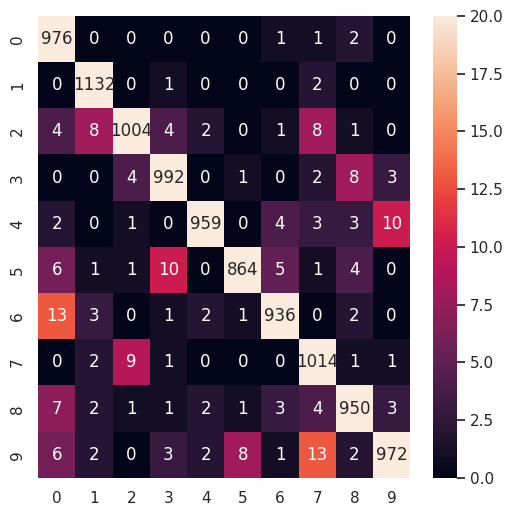

In [17]:
plt.figure(figsize=(6,6))
sns.heatmap(conf, annot=True, fmt='d', vmax=20)
plt.show()


### Testing on own handwritten digits

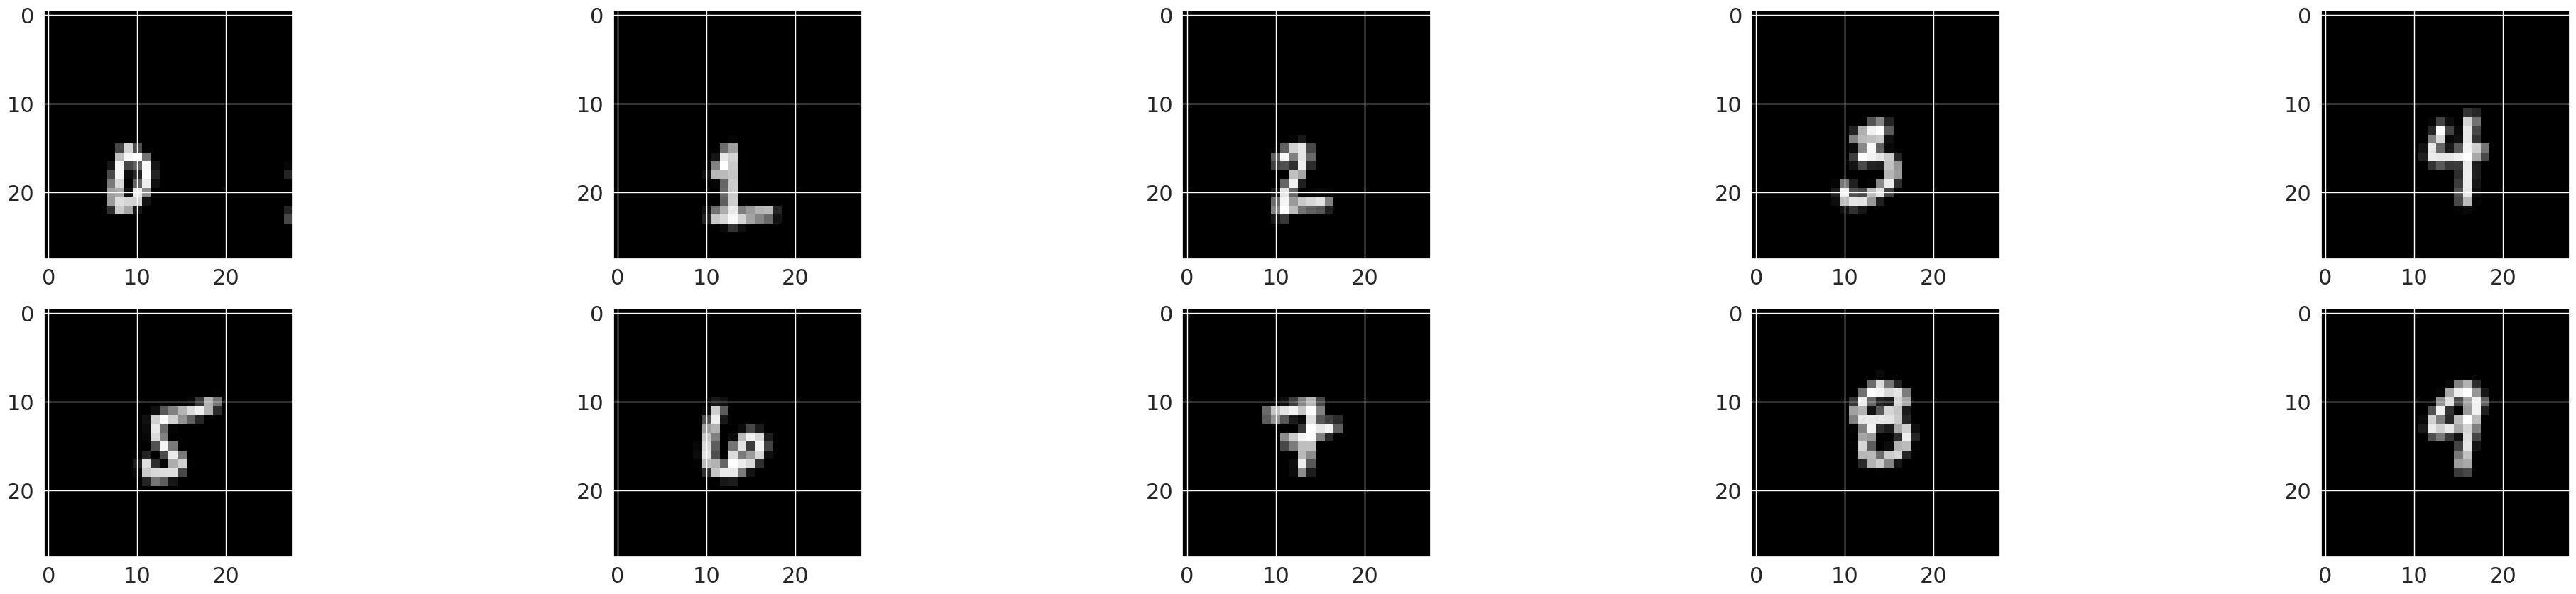

In [74]:
from PIL import Image

sns.set(font_scale = 2)
# visualizing hand-written digits
thresholds = {}
thresholds[ 0 ] = ( 0 , 0 , 500 , 500 ) # top left, bot right
thresholds[ 1 ] = ( 300 , 0 , 800 , 500 )
thresholds[ 2 ] = ( 700 , 0 , 1200 , 500 )
thresholds[ 3 ] = ( 1100 , 0 , 1600 , 500 )
thresholds[ 4 ] = ( 1500 , 0 , 2000 , 500 )
thresholds[ 5 ] = ( 1900, 0 , 2400 , 500 )
thresholds[ 6 ] = ( 2300 , 0 , 2800 , 500 )
thresholds[ 7 ] = ( 2700 , 0 , 3200 , 500 )
thresholds[ 8 ] = ( 3100 , 0 , 3600 , 500 )
thresholds[ 9 ] = ( 3500 , 0 , 4000 , 500 )

plt.figure( figsize = ( 50 , 10 ) )
for i in range( 10 ):
    image = Image.open("/content/drive/MyDrive/ait/numbers.jpg" ).convert('L')
    width, height = image.size
    image = image.crop( thresholds[ i ] )
    image = ImageOps.invert( image )
    image.thumbnail( ( 28 , 28 ) )
    image_data = np.asarray( image , dtype = np.uint8 )
    image_data = image_data / 255
    plt.subplot( 2 , 5 , i + 1 )
    plt.imshow( image_data, cmap = plt.cm.gray )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


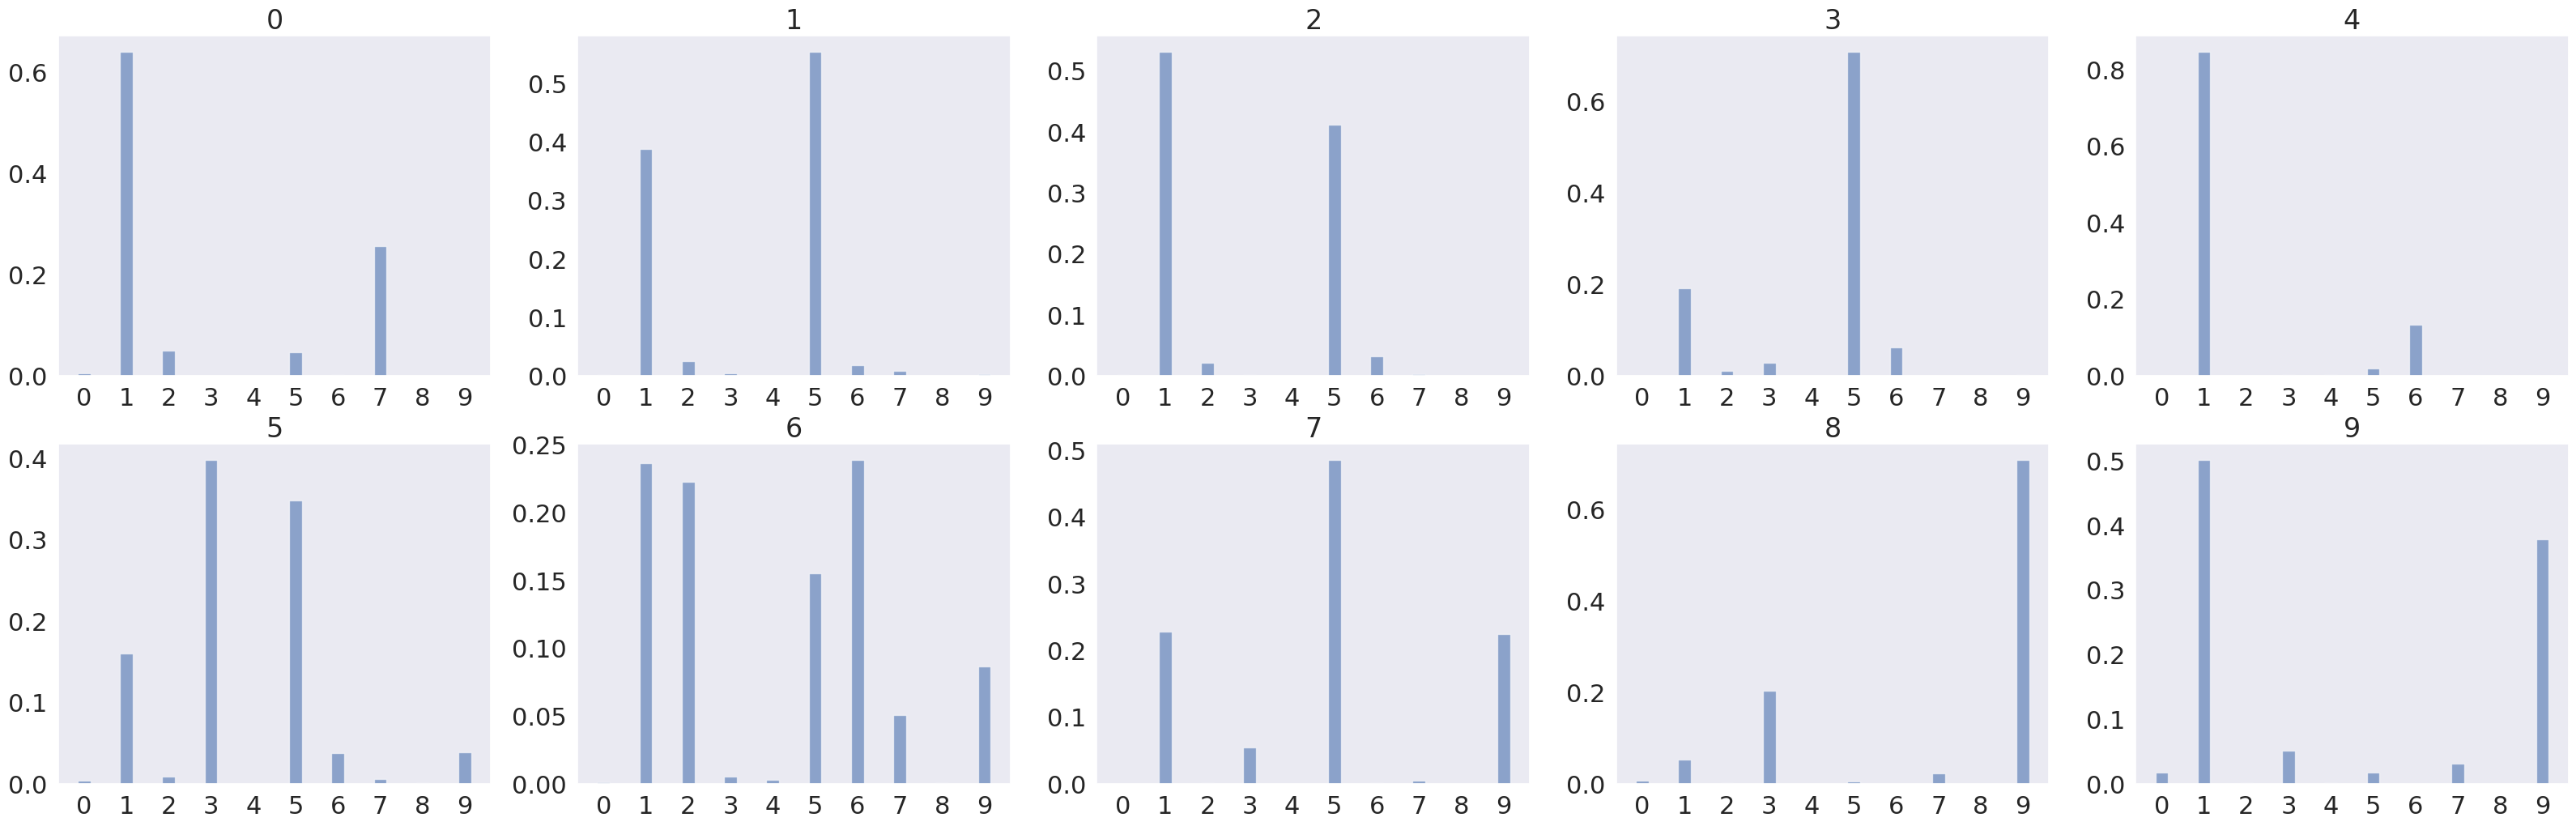

In [75]:
# using the trained model to recognize hand-written digits
plt.figure( figsize = ( 40 , 12 ) )
for i in range( 10 ):
    image = Image.open("/content/drive/MyDrive/ait/numbers.jpg" ).convert('L')
    width, height = image.size
    image = image.crop( thresholds[ i ] )
    image = ImageOps.invert( image )
    image.thumbnail( ( 28 , 28 ) )
    image_data = np.asarray( image , dtype = np.uint8 )
    image_data = image_data / 255
    padded_array = np.pad(image_data, (0, 784 - image_data.size), mode='constant')
    image_data = padded_array.reshape( -1 , 28 , 28 , 1 )

    predictions = model.predict( image_data > 0.8 )
    plt.subplot( 2 , 5 , i + 1 )
    plt.bar( range( 10 ) , predictions[ 0 ] , 0.3 , color = "b" , alpha = 0.6 )
    plt.title( i )
    plt.grid()
    plt.xticks( range( 10 ) )

### Visualize the output of the 2D convolutional layers.

In [76]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Input

# Create model with explicit input layer
inputs = Input(shape=(28, 28, 1))
x = Conv2D(32, (5, 5), strides=(1, 1), activation='relu')(inputs)
x = Conv2D(64, (5, 5), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)
x = Flatten()(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# Load weights
model.load_weights('weights.keras')

# Create activation model
layer_outputs = [model.layers[1].output, model.layers[2].output]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

In [77]:
# first 4 pictures in the test set:
img = x_test[0:4].reshape(-1,28,28,1)
# with labels: 7,2,1,0
np.argmax(y_test[0:4],axis=1)

array([7, 2, 1, 0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


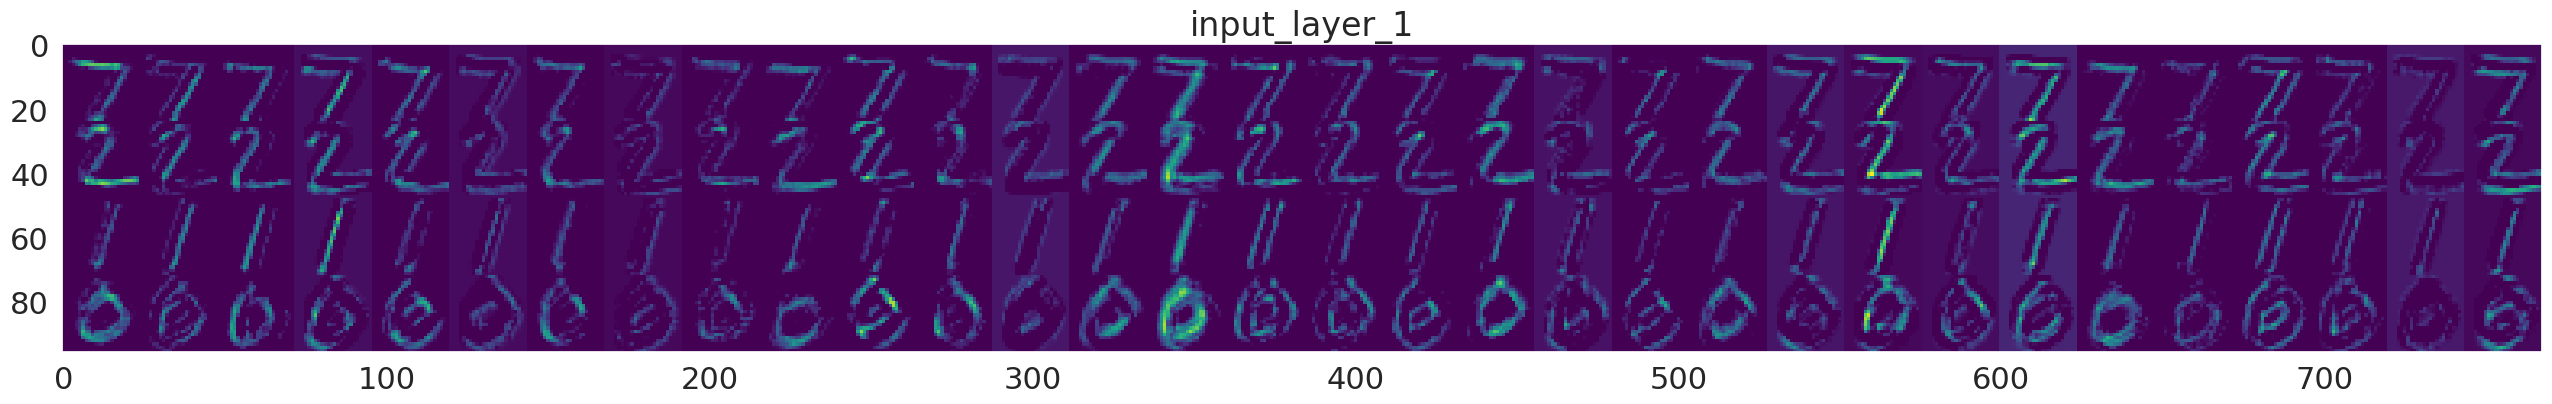

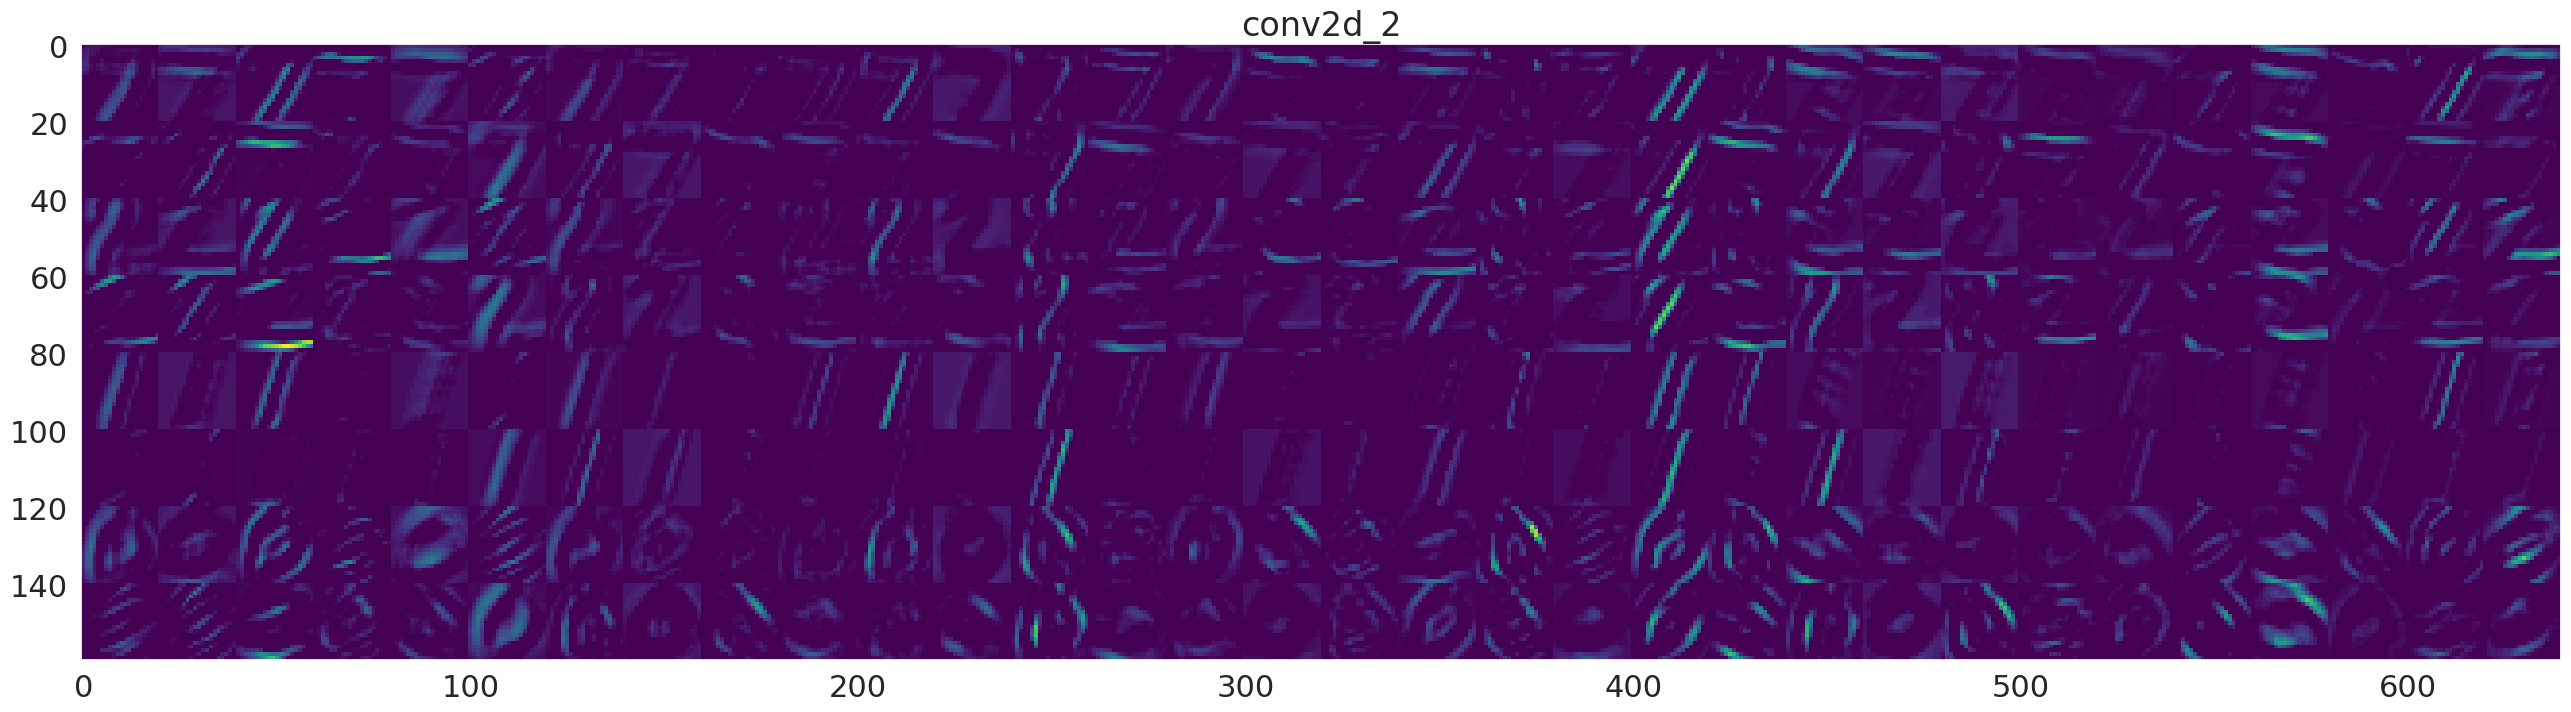

In [78]:
# we won't go through this one, check link 5 below for explanation.
activations = activation_model.predict(img)
layer_names = []
for layer in model.layers[0:2]:
    layer_names.append(layer.name)
images_per_row = 32
for layer_name, layer_activation in zip(layer_names, activations): # Displays the feature maps
    n_features = layer_activation.shape[-1] # Number of features in the feature map
    size = layer_activation.shape[1] #The feature map has shape (1, size, size, n_features).
    n_cols = n_features // images_per_row # Tiles the activation channels in this matrix
    ns= layer_activation.shape[0]
    display_grid = np.zeros((size * n_cols*ns, images_per_row * size))
    for s in range(ns):
      for col in range(n_cols): # Tiles each filter into a big horizontal grid
        for row in range(images_per_row):
            channel_image = layer_activation[s,
                                             :, :,
                                             col * images_per_row + row]
            if False:
              channel_image -= channel_image.mean()
              channel_image /= channel_image.std()
              channel_image *= 64
              channel_image += 128
              channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[(col) * size+ size * n_cols*s: (col + 1) * size+ size * n_cols*s, # Displays the grid
                         row * size : (row + 1) * size] = channel_image
    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

References / Further reading:

1. https://adventuresinmachinelearning.com/neural-networks-tutorial/
2. https://adventuresinmachinelearning.com/python-tensorflow-tutorial/
3. https://adventuresinmachinelearning.com/convolutional-neural-networks-tutorial-tensorflow/
4. http://adventuresinmachinelearning.com/keras-tutorial-cnn-11-lines/
5. https://towardsdatascience.com/visualizing-intermediate-activations-of-a-cnn-trained-on-the-mnist-dataset-2c34426416c8